# MathFound - EXERCISE 3 - MLS FOR IMAGES, CURVES & PCA

### General Rules

**Plagiarism note.** Copying code (either from other students or from external sources) is strictly prohibited! We will be using automatic anti-plagiarism tools, and any violation of this rule will lead to expulsion from the class.

Late submissions up to 24h will be accepted with a penalty, except for extensions in case of serious illness or emergency. In that case please notify the assistant and provide a relevant medical certificate.

**Software.** All exercises of this course use Python.

**What to hand in.** Upload a .zip file of your solution in Moodle. The file must be called `MATHFOUND23-3-firstname-familyname.zip`. The `.zip` file MUST contain the following data inside:

* A jupyter notebook with the solution to the exercise and a description of what you implemented and comments/explanations on your results.

**OR**

* The solution in `.py` format and a `readme.pdf` file containing a description of what you’ve implemented and instructions for running it, as well as explanations/comments on your results.

**Grading** This homework is 8.3% of your final grade. Your submission will be graded according to the quality of the images produced by your program, the conformance of your program to the expected behaviour of the assignment, and your understanding of the underlying techniques used in the assignment. The submitted code must produce exactly the same images included in your submission.

### Goal of this exercise

In this exercise you will apply what you learned about the Moving Least Squares (MLS) method to images and curves. You will read and implement parts of research papers that used MLS. In the second part you will apply PCA for data compression.

## Part 1 - Image deformation using MLS

The first task of this assignment is to write code which deforms images based on moving least squares as presented in the paper "Image Deformation using Moving Least Squares" by Schaefer et al. (provided with the exercise). In this paper, the authors propose a method to smoothly deform images using different kinds of transformations and allow the user to manipulate sets of points and segments to specify the deformations. For this exercise you will only focus on image deformations using sets of points.

Write a program which takes as input an image, some input and output control points and performs the deformation. The algorithm should follow the description from the paper. The three kinds of transformation, i.e. affine, similarity and rigid transformations should be supported by your program. Please note that we don't ask for an interactive application so that you don't need to worry about making the code fast (precomputation of some terms, approximation of the image by a grid), but you can do it if you wish.

Some pointers to help with your implementation:

* Read section 2 of the paper to understand the types of transformations you need to apply.
* Implement backwards warping to avoid artifacts (estimate transformation from the output points to the input points).
* You can use `scipy.ndimage.map_coordinates` to implement the warping process
* To optionally implement the image approximation by a grid for a significant speedup, you can use `numpy.meshgrid` and `scipy.interpolate.griddata`

Your result should resemble the following, where the green and red points are the input and output control points respectively.

![image.png](images/deformed_gingerbread.png)

### Required output

* **Code that deforms images according to user input using all three methods described above (affine, similarity and rigid).**
* **Representative image results of the gingerbread man (provided with the exercise) and at least one more image of your choice.**

### Selecting the control points interactively (optional)

If you want to create an interactive version of your image deformation code, you can look into using `ipywidgets` which allows you to set a callback function when the user clicks on the displayed image (with matplotlib). Any other solution is also fine (for example if you want to make a standalone `.py` for that part :).

#### Solution

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import map_coordinates

In [3]:
def plot_deformed(ax, title: str, image: np.ndarray, p: np.ndarray, q: np.ndarray):
    ax.set_title(title)
    ax.imshow(image)
    ax.scatter(p[:,0], p[:,1], edgecolors="lime", facecolors='none', marker="o")
    ax.scatter(q[:,0], q[:,1], color="red", marker="x")
    ax.axis("off")


In [4]:
def image_map_coordinates(image: np.ndarray, transformed_coordinates_array: np.ndarray):
  # swap the x and y coordinates since image is like (y,x), but the coordinates_arrays we have are in (x,y)
  transformed_coordinates_array_swaped = transformed_coordinates_array[:, [1, 0]]

  deformed_image_channels = []
  for channel in range(image.shape[2]):
    deformed_image_channel = map_coordinates(image[:,:,channel], transformed_coordinates_array_swaped.T, order=3, mode='constant')
    deformed_image_channel = deformed_image_channel.reshape(image.shape[:2])  # Reshape to original image dimensions
    deformed_image_channels.append(deformed_image_channel)

  # Combine the deformed color channels into a single RGB image
  deformed_image = np.stack(deformed_image_channels, axis=2)

  return deformed_image

###For this part, I also tried the models on another image, the result can be found in the "part1" folder.

(404, 348, 3)


<ipython-input-9-6d8ac82bbc1c>:40: RuntimeWarning: divide by zero encountered in divide
  W = 1/np.power(difference, 2 * alpha) #(num_vertices, p.shape[0])


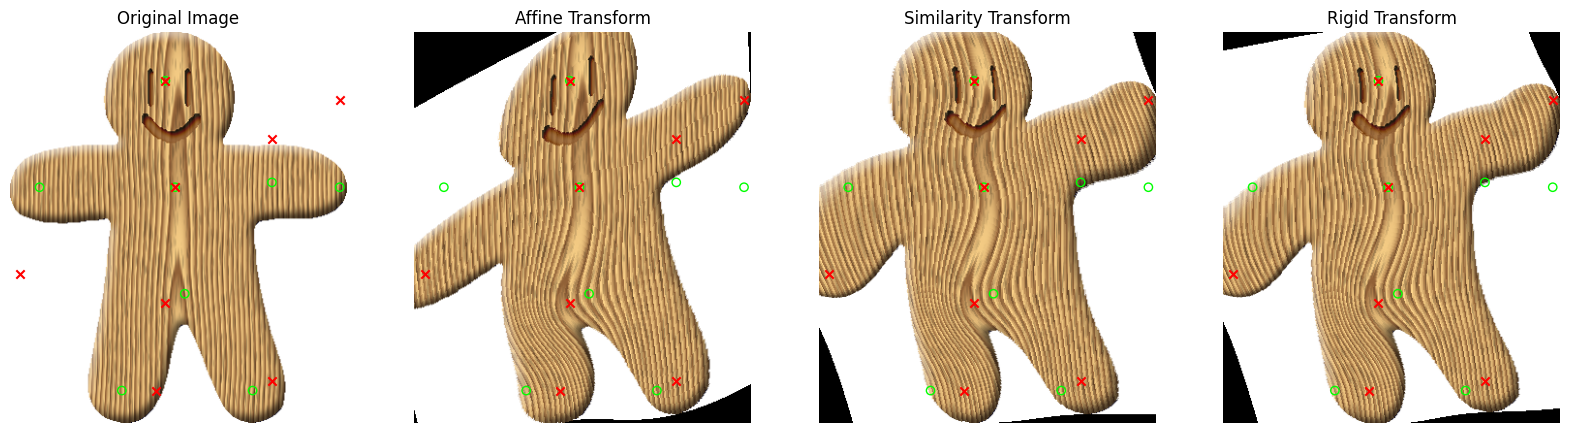

In [9]:
image = plt.imread("data/ginger.png")
print(image.shape)

# control points
p_ori = np.array([[160,50], [170, 160], [180, 270], [30, 160], [270, 155], [340, 160], [115, 370], [250, 370]])

# deformed positions
q_ori = np.array([[160,50], [170, 160], [160, 280], [10, 250], [270, 110], [340, 70], [150, 370], [270, 360]])

# for the image that I chose
#p_ori = np.array([[74, 327], [214, 58], [216, 230], [217, 333], [169, 438],[266, 440], [352, 314], [318, 257]])
#q_ori = np.array([[34, 235], [214, 58], [216, 230], [217, 333], [120, 448], [324, 450], [395, 213], [323, 197]])

# TODO: Implement image deformations
alpha = 1

y_shape = image.shape[0]
x_shape = image.shape[1]
#treat each pixel as a vertex
num_vertices = y_shape * x_shape

x_range = np.arange(1, x_shape+1)
y_range = np.arange(1, y_shape+1)
x_coords, y_coords = np.meshgrid(x_range, y_range)

#(num_vertices,2) array store all coordinates: [[1,1],[2,1],[3,1]...[1,2][2,2]...]
coordinates_array = np.column_stack((x_coords.flatten(), y_coords.flatten()))

# Affine transformation
# Steps are done according to 2.1 of the paper “Image Deformation using Moving Least Squares” by Schaefer et al.
# The only difference is estimating transformation from the output points to the input points to achieve backward warping,
# this requires swapping p and q in the formulas provided by the paper.
p = q_ori
q = p_ori

coordinates_array_reshape = coordinates_array[:, np.newaxis, :]
p_reshape = p[np.newaxis, :, :]
difference = np.linalg.norm(coordinates_array_reshape - p_reshape, axis=2)
# broadcast to calculate for each vertex its weight with p[j,:] where w_ij = 1/|p_j-v_i|^(2*alpha)
W = 1/np.power(difference, 2 * alpha) #(num_vertices, p.shape[0])
#print(W.dtype)
large_number = float('inf')
W = np.nan_to_num(W, nan=large_number)

# calculate the weighted centroids p* and q* for each vertex, where P_star[i,:] is the p* for the ith vertex, similar for Q_star
sum_W_per_vertex = np.sum(W, axis = 1).reshape(-1,1)
W_normalized = W / sum_W_per_vertex
P_star = W_normalized@p # P_star (num_vertices, 2)
Q_star = W_normalized@q # Q_star (num_vertices, 2)

# calculate P_head and Q_head matrices, where P_head_ij is p_j-p*_i for the ith vertex, similar for Q_head
P_star_reshape = P_star[:, np.newaxis, :]
P_head = p_reshape - P_star_reshape # P_head (num_vertices, p.shape[0], 2)

Q_star_reshape = Q_star[:, np.newaxis, :]
q_reshape = q[np.newaxis, :, :]
Q_head = q_reshape - Q_star_reshape # Q_head (num_vertices, p.shape[0], 2)

# using weighted least squares to calculate M_i for each vertex
# x = (A.T@W@A)^(-1)@A.T@W@b for original WLS
# here the diagonal matrix of ith row of W[i,:] is W
# the (8,2) matrix P_head[i,:,:] is A
# the (8,2) matrix Q_head[i,:,:] is b
# the (2,2) result is M_i

# then transform the vertex i with M_i using the formula (v_i−p_star_i)@M + q_star_i
# the transformed vertices are stored in "transformed_coordinates_array"
transformed_coordinates_array_affine = np.zeros_like(coordinates_array) #(num_vertices, 2)
for i in range (num_vertices):
  w = W[i,:]
  w_diag = np.diag(w)
  A = P_head[i,:,:]
  b = Q_head[i,:,:]
  M_i = np.linalg.inv(A.T@w_diag@A)@A.T@w_diag@b

  v_i = coordinates_array[i,:].reshape(1,2)
  p_star_i = P_star[i,:].reshape(1,2)
  q_star_i = Q_star[i,:].reshape(1,2)
  transformed_coordinates_array_affine[i,:] = (v_i-p_star_i)@M_i+q_star_i

deformed_image_affine = image_map_coordinates(image, transformed_coordinates_array_affine)


# Similarity Deformation
# and
# Rigid Deformation (only u_s_i and u_r_i differ)
transformed_coordinates_array_simi = np.zeros_like(coordinates_array) #(num_vertices, 2)
transformed_coordinates_array_rigid = np.zeros_like(coordinates_array) #(num_vertices, 2)
for i in range (num_vertices):
  # compute u_s_i = sum(w_j*p_head_j@h_head_j.T)
  # compute equation (6) of the paper
  u_s_i = 0

  # compute u_r_i as in the paper
  u_r_i_sum1 = 0
  u_r_i_sum2 = 0

  M_i = np.zeros((2,2))
  for j in range (p.shape[0]):
    p_head_i_j = P_head[i,j,:].reshape((1,2))
    u_s_i += W[i,j] * np.sum(p_head_i_j*p_head_i_j)

    p_head_i_j_ortho = np.array([[-p_head_i_j[0,1], p_head_i_j[0,0]]])
    q_head_i_j = Q_head[i,j,:].reshape((1,2))
    q_head_i_j_ortho = np.array(([-p_head_i_j[0,1], p_head_i_j[0,0]]))
    M_i += W[i,j] * np.vstack((p_head_i_j, -p_head_i_j_ortho)) @ np.vstack((q_head_i_j, -q_head_i_j_ortho)).T

    # update u_r_i for rigid deformation
    u_r_i_sum1 += W[i,j] * np.sum(q_head_i_j*p_head_i_j)
    u_r_i_sum2 += W[i,j] * np.sum(q_head_i_j*p_head_i_j_ortho)

  M_i_simi = M_i/u_s_i
  M_i_rigid = M_i/(u_r_i_sum1**2+u_r_i_sum2**2)**0.5

  v_i = coordinates_array[i,:].reshape(1,2)
  p_star_i = P_star[i,:].reshape(1,2)
  q_star_i = Q_star[i,:].reshape(1,2)
  transformed_coordinates_array_simi[i,:] = (v_i-p_star_i)@M_i_simi+q_star_i
  transformed_coordinates_array_rigid[i,:] = (v_i-p_star_i)@M_i_rigid+q_star_i

deformed_image_simi = image_map_coordinates(image, transformed_coordinates_array_simi)
deformed_image_rigid = image_map_coordinates(image, transformed_coordinates_array_rigid)

fig, axes = plt.subplots(1, 4, figsize=(20,18))

for i, title in enumerate(["Original Image", "Affine Transform", "Similarity Transform", "Rigid Transform"]):
  if title == "Original Image":
    plot_deformed(axes[i], title, image, p_ori, q_ori)
  elif title == "Affine Transform":
    plot_deformed(axes[i], title, deformed_image_affine, p_ori, q_ori)
  elif title == "Similarity Transform":
    plot_deformed(axes[i], title, deformed_image_simi, p_ori, q_ori)
  elif title == "Rigid Transform":
    plot_deformed(axes[i], title, deformed_image_rigid, p_ori, q_ori)
  else:
    plot_deformed(axes[i], title, image, p_ori, q_ori)

#axes[0].scatter(p_transformed_array[:,0], p_transformed_array[:,1], edgecolors="green", facecolors='none', marker="o")

plt.show()
plt.close(fig)

## Part 2 - Curve and Surface Reconstruction Using MLS

As described in the lectures, moving least squares (MLS) can be used to approximate a function given samples from that function at sample points. In this exercise, we will utilize this method to reconstruct curves. We provide a few example datasets.

### Implicit MLS Surfaces

Given some samples points and attributes (i.e. normals, colors), we seek to find a function $f(\mathbf{x}) : \mathbb{R}^2 \rightarrow \mathbb{R}$ such that the curve is given by $\mathcal{S} = \{ \mathbf{x} \vert f(\mathbf{x}) = 0, \nabla f(\mathbf{x}) \neq \mathbf{0} \}$

### Curves derivation

MLS based surfaces can be computed by considering different degrees for the local approximations and constraints, as described in the lectures. The first part of the exercise is to derive on paper one of the simplest definitions for MLS based surfaces. For this task, we assume that the locally fit polynomial consists of a single constant term, $f(\mathbf{x}) = c_0$,

$$
\underset{c_0}{\operatorname{argmin}}\sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)(c_0 - f_i(\mathbf{x}))^2
$$

Using the following local functional approximation

$$
f_i(\mathbf{x}) = \mathbf{n_i}^T(\mathbf{x} - \mathbf{x_i})
$$

**derive the closed-form expression for the resulting implicit function** $f(\mathbf{x})$.

Hint: it is a weighted least squares problem for the scalar $c_0$, and hence reduces to a simple normalized average.

#### Solution

### In case there is any compilation error, I also made a screenshot of the derivation. It can be found in "part2/result_1_2_2"

Derivation of the closed-form expression of the ${c_0}$ for the minimization problem:

$$
\underset{c_0}{\operatorname{argmin}}\sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)(c_0 - f_i(\mathbf{x}))^2
$$

$$
\underset{c_0}{\operatorname{argmin}}\sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)(c_0^2 - 2*c_0*f_i(\mathbf{x}) + f_i(\mathbf{x})^2)
$$

$$
\underset{c_0}{\operatorname{argmin}}\sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)*c_0^2 - \sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)*2*c_0*f_i(\mathbf{x}) + \sum_i \phi(||\mathbf{x} - \mathbf{x}_i||) * f_i(\mathbf{x})^2
$$

The expression has value 0 at the derivative with respect to $c_0$ for the optimal $c_0$, so we get:

$$
\sum_i 2*\phi(||\mathbf{x} - \mathbf{x}_i||)*c_0 - \sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)*2*f_i(\mathbf{x}) = 0
$$

$$
\sum_i 2*\phi(||\mathbf{x} - \mathbf{x}_i||)*c_0 = \sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)*2*f_i(\mathbf{x})
$$

$$
c_0 = \frac{ \sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)*f_i(\mathbf{x})} {\sum_i \phi(||\mathbf{x} - \mathbf{x}_i||)}
$$


### Curves plotting

Evaluate the derived $f(\mathbf{x})$ for the given example point sets with 2D points and normals, on a regular grid. For the definition of $\phi$, use a Gaussian of a chosen $\sigma$ such that $\phi(r) = e^{-r^2/\sigma^2}$. Initialize a matrix representing the grid. Then, for each grid center, evaluate the function $f$ and store the value at the entry of the matrix corresponding to that grid. Finally, plot this matrix as a heatmap or similar, overlaid with the sample points in the same image (as shown below). Optionally visualize the zero level set of the matrix (in orange).

![image.png](images/curves.png)

Generate **a few images with different $\sigma$ values to illustrate how it affects the approximation and discuss your results**. You can see the reconstructed curve by observing the values of $f$ close to zero. How is the value of $\sigma$ influencing the results ?

#### Implementation hints

* You can use `imshow` from `matplotlib` to visualize the matrix
* If the plotted $f(\mathbf{x})$ looks too smooth, try decreasing $\sigma$. Similarly, if you get discountinuous $f(\mathbf{x})$, try increasing $\sigma$.
* You can use numpy to load the data:


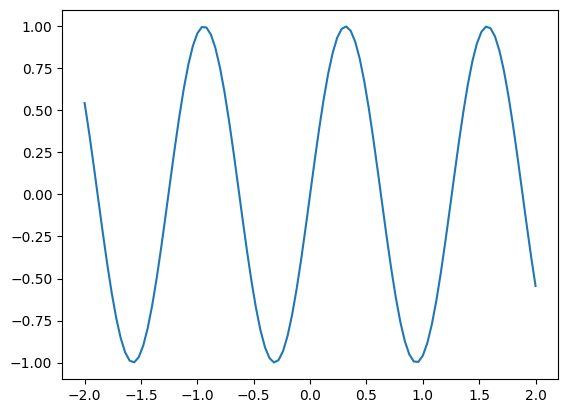

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

curve_data = np.load('data/curve_data1.npz')
points = curve_data['points']
normals = curve_data['normals']

plt.plot(points[:,0], points[:,1])

plt.show()
plt.close()

### Solution

In [ ]:
# Curve plotting functions to help you get started, feel free to modify
import matplotlib.colors

def plot_curve(fig, ax, points, x, y, grid):
    extent = (np.min(x), np.max(x), np.min(y), np.max(y))
    norm = matplotlib.colors.TwoSlopeNorm(vcenter=0.0)

    mappable = ax.imshow(grid, origin="lower", extent=extent, cmap="RdBu", norm=norm)
    ax.plot(points[:,0], points[:,1], color="blue")
    ax.contour(x, y, grid, levels=[0], colors="orange")

    fig.colorbar(mappable, ax=ax)

I operated with different alpha values, you could find the images in the "part2/change_sigma" folder. "sigma_*" means "*" is used as the sigma value.

For a given x, sigma decides the amount of points taken into consideration.

For a small sigma, only points very close to x take enough big weights to be considered. For example, for sigma = 0.01 and sigma = 0.05, we see white areas in the upper parts near the borders. This happens because the grid centers in this area are too far from the points. Given a small sigma value, all weights of the points approach zero. In my code, I make those grids have value 0.

Small sigma values have the benefit that the resulting curve fits better to the original one, since only surrounding points with the same trend are considered. But it leads to discontinous f(x), since it focus more on the local changes.

Big sigma values on the contrary take a wider range of points into consideration, and thus provide more global and smooth solution. However, it leads to poor solution especially for functions with big changes and high frequency (e.g. the curve1).

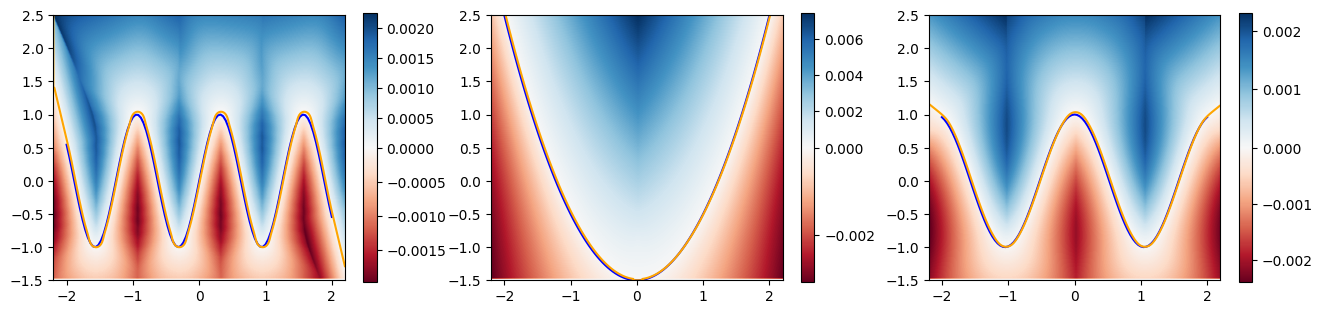

In [ ]:
NX, NY = 300, 200  # grid resolution
x_axis = np.linspace(-2.2, 2.2, NX)
y_axis = np.linspace(-1.5, 2.5, NY)

# length of half of a grid in x and y direction
half_x_grid = 4.4/(NX-1)
half_y_grid = 4/(NY-1)
sigma = 0.1

fig, axis = plt.subplots(1, 3, figsize=(16, 3.5))

for curve_i, ax in enumerate(axis):
    curve_data = np.load(f'data/curve_data{curve_i + 1}.npz')
    points = curve_data['points']
    normals = curve_data['normals']  # not normalized!

    #grid = np.ascontiguousarray([x_axis] * NY)

    # TODO - fill the `grid` with f(x) values
    grid = np.zeros((NY, NX))
    num_points = points.shape[0]

    for i, x in enumerate(x_axis):
      for j, y in enumerate(y_axis):
        if i!=0 and j!=0:
          center_of_grid_x = x - half_x_grid
          center_of_grid_y = y - half_y_grid
          center_of_grid = np.array([center_of_grid_x, center_of_grid_y])

          # compute x-x_i
          diff_center_points = center_of_grid - points

          # compute f_i(x) which is the dot product of n_i and (x-x_i)
          f_ix = np.sum(diff_center_points * normals, axis=1)

          # compute the weights e^(-||x-x_i||^2/sigma^2)
          # first, compute ||x-x_i||^2
          w = np.linalg.norm(diff_center_points, axis=1)**2
          w = -w/(sigma**2)
          w = np.exp(w)

          # compute sum of w_i * f_i(x)
          product = w * f_ix
          sum_of_product = np.sum(product)

          # compute sum of w_i
          sum_of_weight = np.sum(w)

          #c0 = sum_of_product/sum_of_weight
          if sum_of_weight != 0:
            c0 = sum_of_product / sum_of_weight
            grid[j, i] = c0

    plot_curve(fig, ax, points, x_axis, y_axis, grid)


#### Bonus exercise - numerically stable implementation

_Added to Exercise 3, maximum points cannot exceed 100%_

You will observe that with small $\sigma$, the function $f$ becomes numerically unstable at some regions of the grid. Dervive and implement numerically stable verison of $f(\mathbf{x})$ with the given $\phi(r)$

## Part 3 - Image Compression using PCA

As described in the lecture, PCA is a powerful technique commonly used in machine learning and image processing to reduce the dimensions of data while preserving its important features. This is particularly useful when working with large datasets, as it can help reduce the computational complexity of your algorithms while maintaining the quality of the data.

In this small exercise, you will use PCA to compress a **single** image by reducing the number of dimensions along its rows. This will help you gain a better understanding of how PCA works and how it can be used in real-world applications. You will be given a sample image, and your task will be to apply PCA to it to reduce its dimensions while minimizing the loss of information.

You will be given two programming tasks to complete:

### Plotting Reduced Images:
Write a Python function `pca_on_cols(image, n_comps)` that takes an image and an integers n_comps as input and plots the compressed/reconstructed image obtained by projecting the image rows onto n_comps principal components.
To test the function and compare different results depending on the number of used principal components, run the function `plot_reduced_images(image, n_comps)` that takes the test image and a list of integers n_comps as input and plots the compressed/reconstructed images obtained by calling your `pca_on_cols` function.

### Plotting Variance vs. Components:
Write a Python function `plot_variance_vs_components(image)` that takes an image as input and plots the variance maintained as a function of the number of principal components kept. This will help you to determine how many principal components to keep in order to achieve a desired level of compression.

*Hint:* You are allowed to use [sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to solve the tasks

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from typing import Tuple, List
from sklearn.decomposition import PCA

In [ ]:
def pca_on_cols(image: np.ndarray, n_comps: int) -> Tuple[np.ndarray, np.ndarray]:
    """Applies PCA on the rows of the image, separately on the three color channels and reconstructs
    the image using the reduced representations of each color channel.

    Args:
            image (ndarray) - Input image of shape (height, width, 3) where 3 represents the three color
                                channels (blue, green, red).
            n_comps (int)   - Number of principal components to keep for each color channel

    Returns:
            A tuple containing the reconstructed image of the same shape as the input image, and
            the cumulative explained variance ratio averaged over the PCA for each color channel.
    """

    img_reduced = np.zeros_like(image)
    explained_variance = 0

    #TODO START
    num_rows = image.shape[0]

    # store the explained variance ratios for each channel
    explained_variance = np.zeros((image.shape[2], n_comps))

    for i in range(image.shape[2]):
      channel_i = image[:,:,i]

      # center the rows
      sum_rows = np.sum(channel_i, axis = 0)
      average_rows = sum_rows/num_rows
      channel_i = channel_i - average_rows

      pca = PCA(n_components=n_comps)
      # compute the principal components
      pca.fit(channel_i)

      # get the cumulative explained variance ratio
      explained_variance[i,:] = np.cumsum(pca.explained_variance_ratio_)

      # project the rows to reduce dimensions
      transformed_channel_i = pca.transform(channel_i)

      # reconstruct the compressed image
      compressed_channel_i = pca.inverse_transform(transformed_channel_i)

      # add back the average
      compressed_channel_i = compressed_channel_i + average_rows

      img_reduced[:,:,i] = compressed_channel_i

    explained_variance = np.mean(explained_variance, axis = 0)

    #TODO END
    return img_reduced, explained_variance

In [ ]:
def plot_variance_vs_components(image):
    """Computes the cumulative explained variance of principal component analysis (PCA) on each color
    channel of an input image and plots it against the number of principal components.

    Args:
        image (np.ndarray) - Input image of shape (height, width, 3) where 3 represents the three color
                             channels (blue, green, red).

    Plots:
        A line plot of the cumulative explained variance vs. the number of principal components.
    """
    cumulative_variance = 0
    #TODO START
    _, cumulative_variance = pca_on_cols(image, 250)
    #TODO END
    plt.plot(cumulative_variance)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Cumulative Explained Variance vs. Number of Principal Components')
    plt.show()

In [ ]:
def plot_reduced_images(image: np.ndarray, n_comps: List[int]):
    """Reduces an input image using principal component analysis (PCA) with different numbers of
    components and plots the reduced images side by side.

    Args:
        image (np.ndarray) - Input image of shape (height, width, 3) where 3 represents the three color
                             channels (blue, green, red).
        n_comps (int or List[int]) - Number(s) of principal components to use for reducing the image.

    Plots:
        A grid of reduced images, one for each number of principal components specified in n_comps.
    """
    _, axes = plt.subplots(nrows=5, ncols=2, figsize=(15,24))
    i = 0

    for n in n_comps:
        ax = axes.flat[i]
        image_reduced, _ = pca_on_cols(image, n_comps = n)
        ax.imshow(image_reduced)
        ax.set_axis_off()
        ax.set_title(f"Reduced image on {n} components")
        i += 1

    plt.tight_layout()
    plt.show()

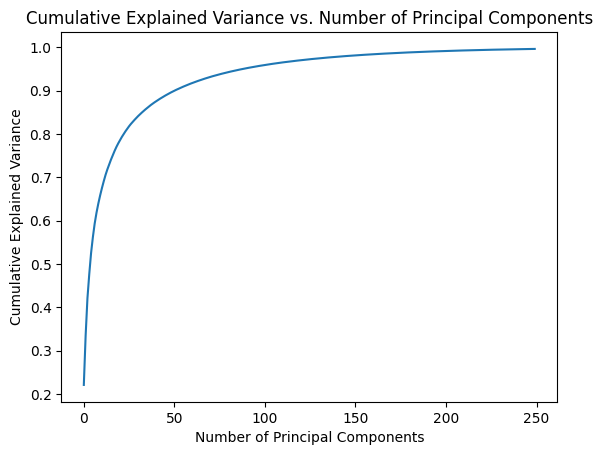

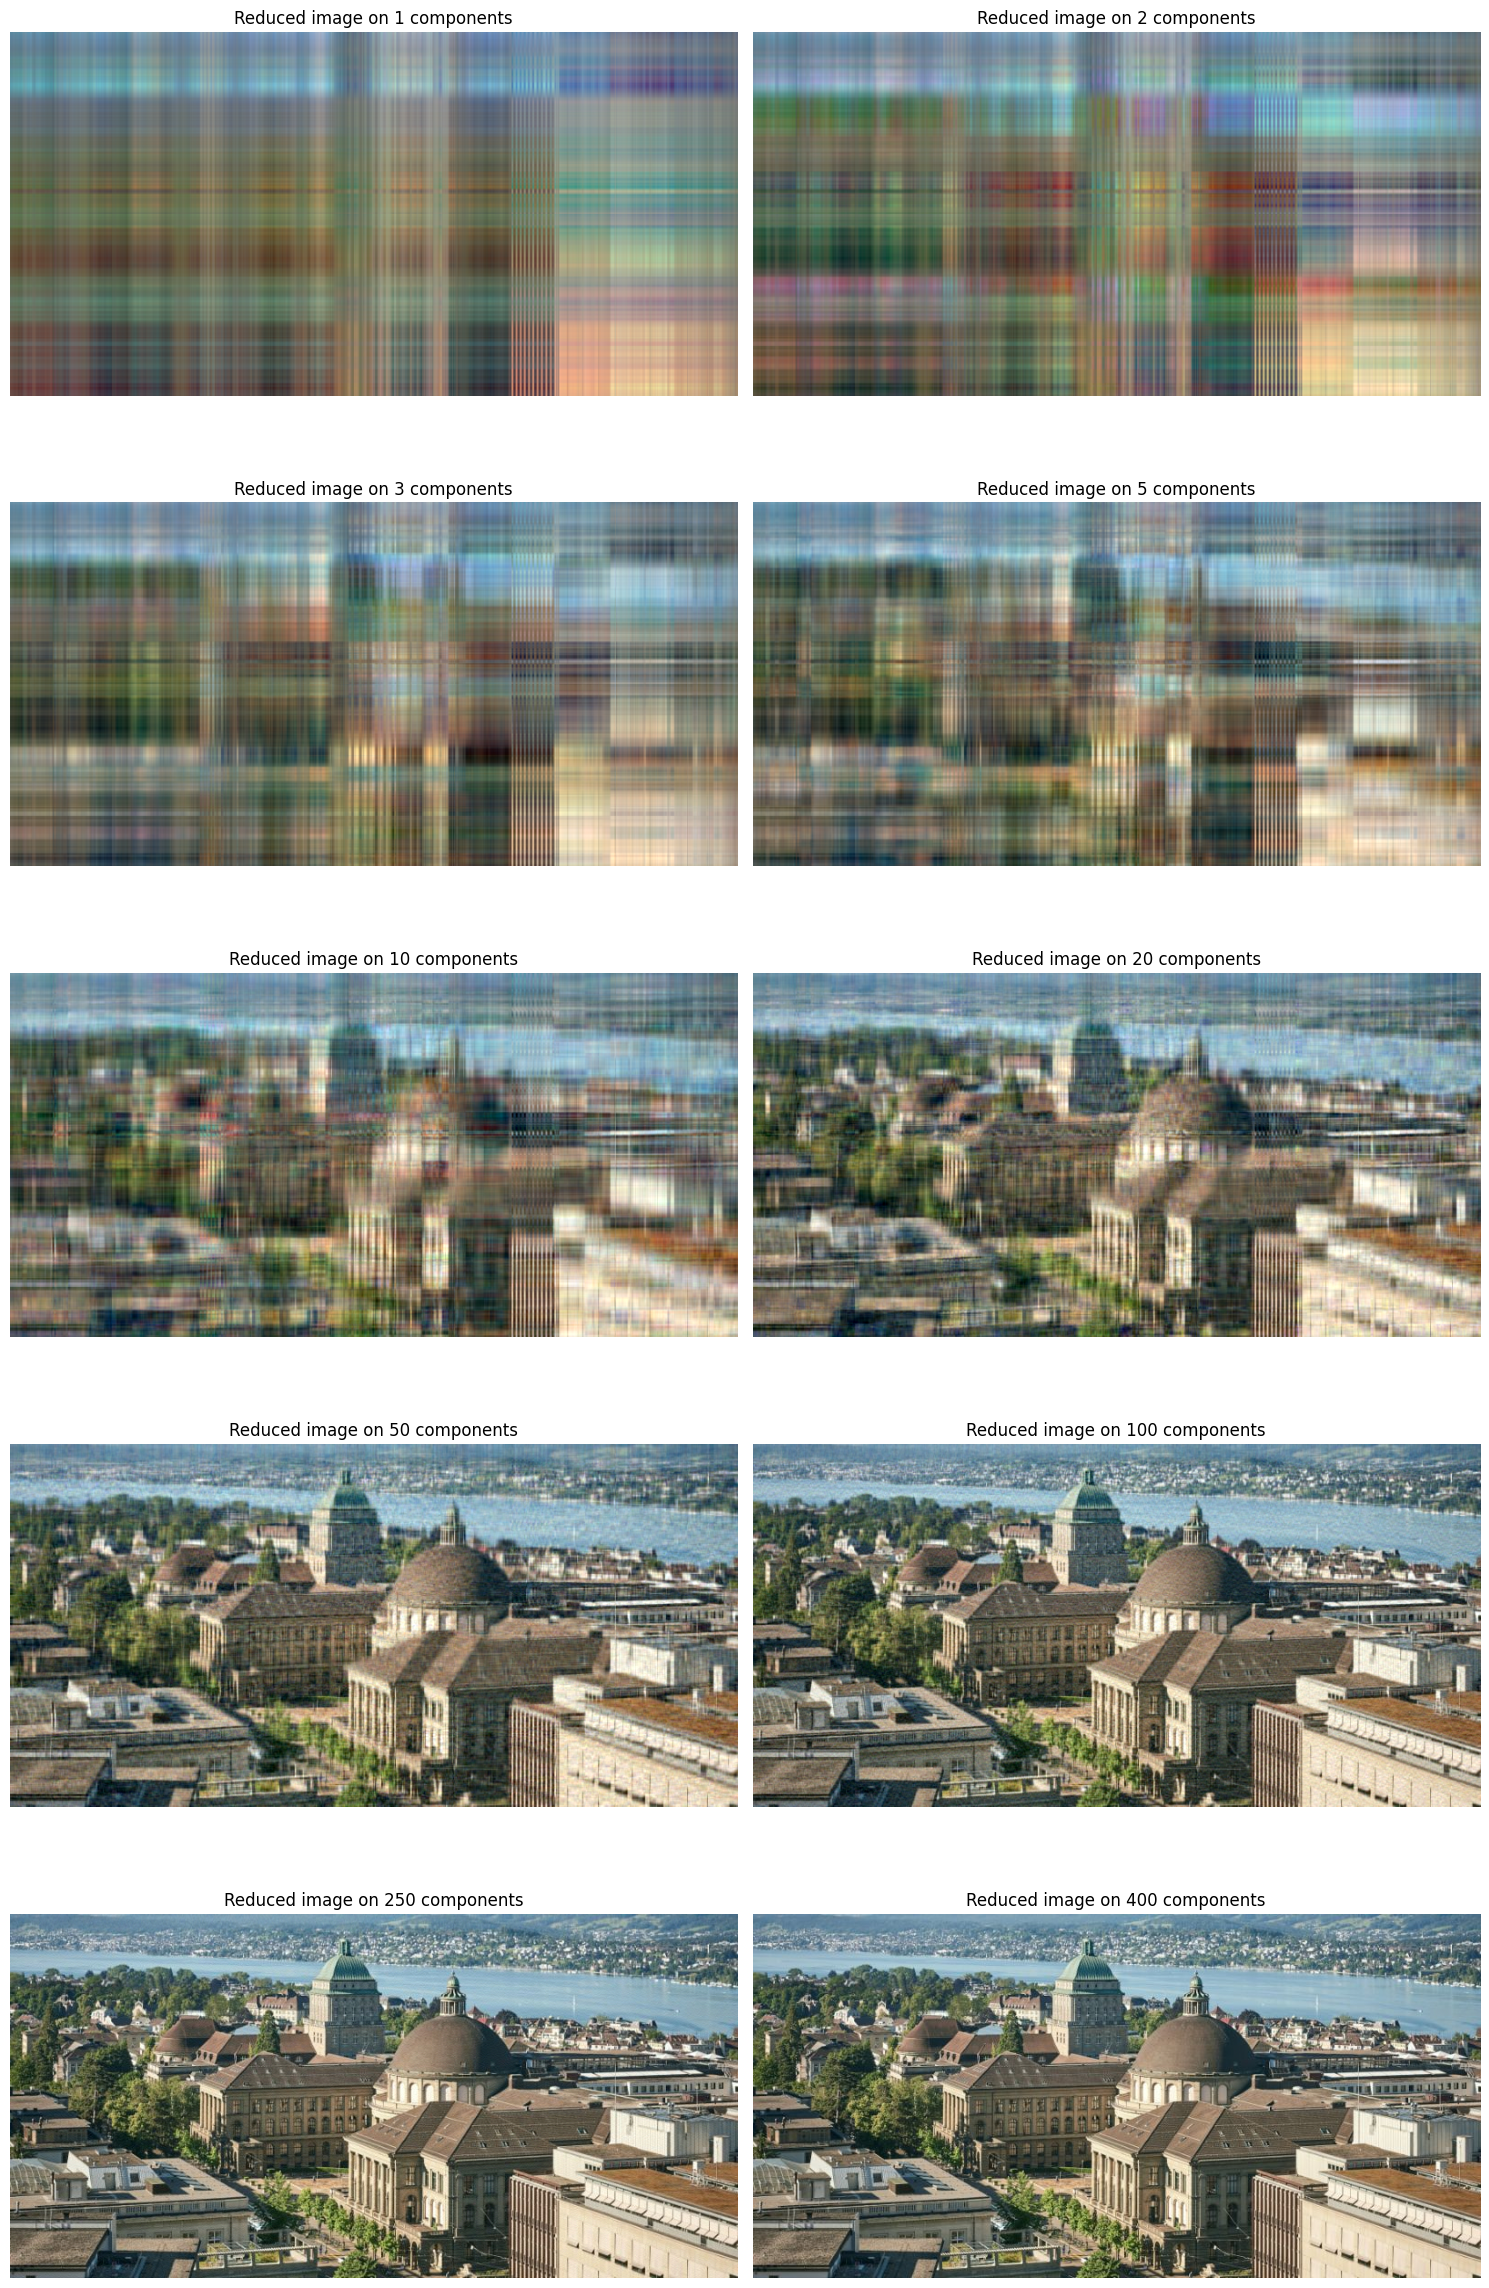

In [ ]:
image = plt.imread('data/ethz.png')

plot_variance_vs_components(image)
plot_reduced_images(image, n_comps = [1, 2, 3, 5, 10, 20, 50, 100, 250, image.shape[0]])

### Theoretical question
Imagine now you are given $N$ RGB face images $\{\mathbf{x}_i\}_{i=1}^N$ of size $3\times H\times W$ and you want to compress them along the rows as you have done for a single image in the programming part (i.e. perform PCA along the rows for each color channel separately). As you already know, this can be done by computing the eigenfaces $\mathbf{u}_k$ of these images and representing the images as a linear combination of eigenfaces:
$$\mathbf{\hat{x}}_i = \sum_{k=1}^K [z_{i,k} \mathbf{u}_k] + \mathbf{\bar{x}}$$
You have already implemented your pipeline. To obtain the eigenfaces, you have been following the generic procedure

* Split image into three parts for each channel and make each part 1D
* Calculate the per-pixel mean image for each color channel
* Normalize the images (subtract mean from all images)
* Generate the covariance matrices for each part
* Get Eigenvectors of the covariance matrix for each part
* Keep the Eigenvectors with the $K$ largest Eigenvalues for each part

In this procedure you need to specify the number of eigenfaces $K$ manually. The more eigenfaces you use the better the compression but the more storage space is needed. **What is the maximal value for $K$ with which you can still reduce storage space by compression?**

Please consider all information required to decompress an image or compress a new one. Note that you are storing images as arrays (e.g. the original images are stored as arrays of size $3\times H\times W$ each) and are not using any other compression like JPEG etc.. We assume that all numbers and array entries take the same amount of storage space.

#### Answer

### Same as other theoretical questions, I made a screenshot of the answer, it can be found in "part3/result1_3_3".

Your answer here (Type *Markdown* and LaTeX: $\alpha^2$)

#### Storage space without eigenfaces:
$$N\times 3\times H\times W$$

#### Storage space with eigenfaces:
If we store $K$ eigenfaces, we need $K\times 3\times H\times W$ storage.

Also, for decompress the image, as the formula
$$\mathbf{\hat{x}}_i = \sum_{k=1}^K [z_{i,k} \mathbf{u}_k] + \mathbf{\bar{x}}$$ suggests, we need for each image, $K$ coefficients (each for one eigen face) for each color channel. So we need $N\times 3\times K$ storage for the coefficients. Furthermore, we need the per-pixel mean image for each color channel, which is $3\times H\times W$ storage.

For compress a new image, what we do is subtract the mean image from the new image and project it to the space of the eigenfaces to get coefficients. So what we need is also the per-pixel mean image and the $K$ eigenfaces. All used data in this part are mentioned in the decompression part, no further storage needed.

#### So the equation we get is:

$$K\times 3\times H\times W + N\times 3\times K + 3\times H\times W < N\times 3\times H\times W $$

$$K\times H\times W + N\times K + H\times W < N\times H\times W $$

$$K\times (H\times W + N) + H\times W < N\times H\times W $$

$$K\times (H\times W + N) < N\times H\times W - H\times W$$

$$K < \frac{N\times H\times W - H\times W}{H\times W + N}$$

In summary, $K$ needs to be smaller than $\frac{N\times H\times W - H\times W}{H\times W + N}$ to still reduce storage by compression.
